In [1]:
import pandas as pd
import numpy as np
import pickle

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

In [3]:
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv1D, MaxPooling1D, Dense, Flatten, Activation, ZeroPadding2D
from tensorflow.keras.layers import LSTM, Embedding, Bidirectional, TimeDistributed, Reshape, Dropout
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
import time
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [5]:
import kerastuner as kt
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

d:\conda\envs\CNN\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  """Entry point for launching an IPython kernel.


In [6]:
import random
from numpy.random import seed
import tensorflow
from keras.layers import Input, Dense
from keras.models import Model
from keras.layers.merge import Concatenate
import argparse

In [7]:
import os

In [ ]:
#Your own path to MLforSTCP
os.chdir(r'C:\Users\ADMIN\Desktop\MLforSTCP')

In [ ]:
DF1 = pd.read_csv(r'.\Datasets\Benchmark\FF_80.csv').dropna(subset=['TC'])
DF1

,TC,mass_H,mass_C,mass_N,mass_O,mass_F,mass_P,mass_S,mass_Cl,mass_Br,...,k_dih_70,k_dih_71,k_dih_72,k_dih_73,k_dih_74,k_dih_75,k_dih_76,k_dih_77,k_dih_78,k_dih_79
0,0.456185,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,0.258773,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,0.264363,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,0.261131,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,0.234342,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,0.239876,0.415810,0.718493,0.688310,0.615030,0.451879,0.025425,0.017123,0.004314,5.120000e-22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1073,0.248861,0.415810,0.718493,0.688310,0.615030,0.451879,0.025425,0.017123,0.004314,5.120000e-22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1074,0.208098,0.554641,0.555102,0.510087,0.443512,0.317039,0.062834,0.059515,0.046897,1.520000e-14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1075,0.199093,0.416893,0.654673,0.622982,0.552476,0.400711,0.089796,0.085726,0.068309,2.220000e-14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


In [10]:
DF=DF1.drop('TC', axis=1)
DF

,mass_H,mass_C,mass_N,mass_O,mass_F,mass_P,mass_S,mass_Cl,mass_Br,mass_I,...,k_dih_70,k_dih_71,k_dih_72,k_dih_73,k_dih_74,k_dih_75,k_dih_76,k_dih_77,k_dih_78,k_dih_79
0,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,1.520000e-73,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,1.520000e-73,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,1.520000e-73,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,1.520000e-73,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,0.739014,0.478028,0.396042,0.311840,0.191260,0.003575,0.002086,0.000325,1.830000e-26,1.520000e-73,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,0.415810,0.718493,0.688310,0.615030,0.451879,0.025425,0.017123,0.004314,5.120000e-22,1.690000e-65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1073,0.415810,0.718493,0.688310,0.615030,0.451879,0.025425,0.017123,0.004314,5.120000e-22,1.690000e-65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1074,0.554641,0.555102,0.510087,0.443512,0.317039,0.062834,0.059515,0.046897,1.520000e-14,2.710000e-51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1075,0.416893,0.654673,0.622982,0.552476,0.400711,0.089796,0.085726,0.068309,2.220000e-14,3.960000e-51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


In [11]:
finger=[]
sigma=80
for k in range(len(DF)):
    desc=np.zeros(sigma).reshape(1,-1)
    data=DF.iloc[k].values
    for i in range(10):
        desc[0][i]=data[i]
    desc1=data[10:].reshape(-1,sigma)
    desc2=np.zeros(sigma*(sigma-10)).reshape(-1,sigma)
    finger.append(np.vstack([desc,desc1,desc2]))
finger=np.array(finger)

In [12]:
finger.shape

(1070, 80, 80)

In [ ]:
finger_shape=finger.shape
finger1=finger.reshape(finger_shape[0],finger_shape[1],finger_shape[2],1)

In [15]:
# data split into train/test sets 
X_train, X_test, y_train, y_test = train_test_split(finger1, DF1['TC'].astype(np.float64), test_size=0.2, random_state=13)

In [16]:

def build_model(hp):
    model = Sequential()
    model.add(Conv2D(
       filters=hp.Int('conv_filter_0',min_value=8,max_value=32,step=8),
       kernel_size=hp.Int('kernal_size_0',min_value=8,max_value=12,step=2),
       activation='relu',
       input_shape=X_train.shape[1:]))
    model.add(Conv2D(
       filters=hp.Int('conv_filter_1',min_value=8,max_value=32,step=8),
       kernel_size=hp.Int('kernal_size_1',min_value=4,max_value=8,step=2),
       activation='relu'))   
    model.add(Conv2D(
       filters=hp.Int('conv_filter_2',min_value=8,max_value=32,step=8),
       kernel_size=hp.Int('kernal_size_2',min_value=2,max_value=4,step=1),
       activation='relu'))   
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(hp.Float("Dropout", min_value=0, max_value=0.3,step = 0.1, default = 0.3)))
    model.add(Flatten())
    model.add(Dense(1))
    optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', values=[0.01,0.05,0.001]))
    model.compile(optimizer=optimizer, loss='mean_squared_error',metrics="mean_absolute_error")
    return model

In [17]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_mean_absolute_error",
    max_trials=50,
    seed=11,
    directory='my_dir1', 
    project_name='helloworld'
)

INFO:tensorflow:Reloading Tuner from my_dir1\helloworld\tuner0.json


In [18]:
tuner.search(
    X_train,
    y_train,
    epochs=200, 
    validation_data=(X_test, y_test)
)

INFO:tensorflow:Oracle triggered exit


In [19]:
CNN_model = tuner.get_best_models(1)[0]
tuner.results_summary()

Results summary
Results in my_dir1\helloworld
Showing 10 best trials
Objective(name="val_mean_absolute_error", direction="min")

Trial 33 summary
Hyperparameters:
conv_filter_0: 32
kernal_size_0: 10
conv_filter_1: 32
kernal_size_1: 8
conv_filter_2: 16
kernal_size_2: 2
Dropout: 0.0
learning_rate: 0.001
Score: 0.0158590879291296

Trial 01 summary
Hyperparameters:
conv_filter_0: 24
kernal_size_0: 12
conv_filter_1: 8
kernal_size_1: 8
conv_filter_2: 32
kernal_size_2: 4
Dropout: 0.1
learning_rate: 0.001
Score: 0.01615907810628414

Trial 48 summary
Hyperparameters:
conv_filter_0: 16
kernal_size_0: 8
conv_filter_1: 8
kernal_size_1: 8
conv_filter_2: 8
kernal_size_2: 2
Dropout: 0.1
learning_rate: 0.001
Score: 0.016596008092164993

Trial 23 summary
Hyperparameters:
conv_filter_0: 24
kernal_size_0: 10
conv_filter_1: 24
kernal_size_1: 4
conv_filter_2: 16
kernal_size_2: 2
Dropout: 0.0
learning_rate: 0.001
Score: 0.016690272837877274

Trial 07 summary
Hyperparameters:
conv_filter_0: 8
kernal_size_0: 

In [20]:
# model evaluation
y_pred_train = CNN_model.predict(X_train)
y_pred_test = CNN_model.predict(X_test)
print("model performance")
print("Train set R^2: %.2f" % r2_score(y_train, y_pred_train))
print("Train MAE score: %.2f" % mean_absolute_error(y_train, y_pred_train))
print("Train RMSE score: %.2f" % np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Test set R^2: %.2f" % r2_score(y_test, y_pred_test))
print("Test MAE score: %.2f" % mean_absolute_error(y_test, y_pred_test))
print("Test RMSE score: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred_test)))

model performance
Train set R^2: 0.94
Train MAE score: 0.01
Train RMSE score: 0.02
Test set R^2: 0.86
Test MAE score: 0.02
Test RMSE score: 0.02


In [22]:
import matplotlib.pyplot as plt

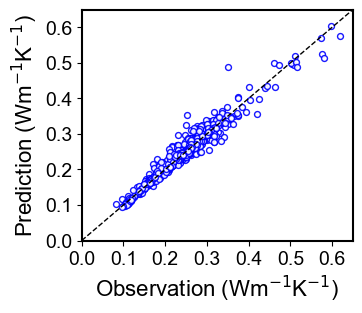

In [ ]:
plt.figure(figsize=(3.5,3))
ax=plt.subplot(1, 1, 1)
plt.scatter(y_train, y_pred_train, c='white', marker='o', s = 18, edgecolors='blue', alpha=0.9,linewidths = 1)
# plt.scatter(y_test, y_pred_test, c='#ff7f0e', marker='o', s = 18, edgecolors='k', linewidths = 0.2) 
plt.plot([0,0.65],[0,0.65], color='k', linewidth=1.0, linestyle='--')
plt.xlabel("Observation (Wm$^{-1}$K$^{-1}$) ",fontname="Arial", fontsize=16)
plt.ylabel("Prediction (Wm$^{-1}$K$^{-1}$)",fontname="Arial", fontsize=16)
x0, x1 = min(y_train), max(y_train)
length = 750
plt.xlim([0, 0.65])
plt.ylim([0, 0.65])
ax.set_xticks([0,0.1,0.2,0.3,0.4,0.5,0.6])
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6])
# ax.set_yticks([-200,-100,0,100,200,300,400,500])
plt.xticks(fontname="Arial", fontsize=14, fontweight='normal')
plt.yticks(fontname="Arial", fontsize=14, fontweight='normal')
TK = plt.gca()
bwith=1.5
TK.spines['bottom'].set_linewidth(bwith)
TK.spines['left'].set_linewidth(bwith)
TK.spines['top'].set_linewidth(bwith)
TK.spines['right'].set_linewidth(bwith)
plt.show()

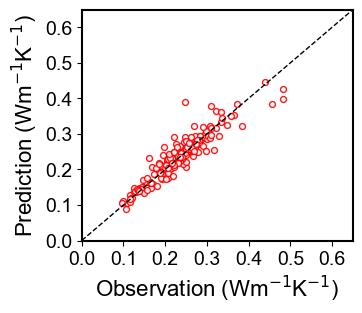

In [ ]:
plt.figure(figsize=(3.5,3))

ax=plt.subplot(1, 1, 1)
# plt.scatter(y_train, y_pred_train, c='white', marker='o', s = 18, edgecolors='blue', alpha=0.9,linewidths = 1)
plt.scatter(y_test, y_pred_test, c='white', marker='o', s = 18, edgecolors='r', alpha=0.9,linewidths = 1) 
plt.plot([0,0.65],[0,0.65], color='k', linewidth=1.0, linestyle='--')
plt.xlabel("Observation (Wm$^{-1}$K$^{-1}$) ",fontname="Arial", fontsize=16)
plt.ylabel("Prediction (Wm$^{-1}$K$^{-1}$)",fontname="Arial", fontsize=16)
x0, x1 = min(y_train), max(y_train)
length = 750
plt.xlim([0, 0.65])
plt.ylim([0, 0.65])
ax.set_xticks([0,0.1,0.2,0.3,0.4,0.5,0.6])
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6])
# ax.set_yticks([-200,-100,0,100,200,300,400,500])
plt.xticks(fontname="Arial", fontsize=14, fontweight='normal')
plt.yticks(fontname="Arial", fontsize=14, fontweight='normal')
TK = plt.gca()
bwith=1.5
TK.spines['bottom'].set_linewidth(bwith)
TK.spines['left'].set_linewidth(bwith)
TK.spines['top'].set_linewidth(bwith)
TK.spines['right'].set_linewidth(bwith)
plt.show()